In [ ]:
from itables import init_notebook_mode, show
import numpy as np
import torch
from torchviz import make_dot
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import importlib
import aacbr_torch

init_notebook_mode(all_interactive=True)

In [ ]:
def reload_imports():
    importlib.reload(aacbr_torch)

## Data Set

In [ ]:
# from ucimlrepo import fetch_ucirepo 
  
# # fetch dataset 
# connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151) 
  
# # data (as pandas dataframes) 
# X = connectionist_bench_sonar_mines_vs_rocks.data.features 
# y = connectionist_bench_sonar_mines_vs_rocks.data.targets 

data = pd.read_csv('data/connectionist-bench-sonar-mines-vs-rocks/sonar.all-data')

data = data.values

X = np.array(data[:, :-1], dtype=np.float32)
y = np.array(data[:, -1])

show(X)
print(np.unique(y))



In [ ]:
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)


In [ ]:
print(encoder.classes_)
print(y)
print(type(y))

## Train Model

### Split into Training and Test Sets

In [ ]:
SEED = 42

In [ ]:
X, y = torch.tensor(X, requires_grad=True), torch.tensor(y, requires_grad=True, dtype=torch.float32)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED)
print(f"Test Size:  {len(X_test)}")
print(f"Train Size:  {len(X_train)}")
print(f"Validation Size:  {len(X_val)}")



In [ ]:
print(X_train)

### Build AF

In [ ]:
# TODO: Consider more sophisticated orders

# Compare against the average for each column
means = X_train.mean(axis=0)
std = X_train.std(axis=0)

STD_PARAM = 2

def binarise_by_normal(case):
    
    return torch.where(torch.abs(case - means) <= STD_PARAM * std, 0, 1)


def strictsuperset(a, b):

    if b.ndim == 1:
        b = b.unsqueeze(0)


    anb = a & b
    return torch.logical_and(torch.all(anb == b, axis = -1), torch.logical_not(torch.all(anb == a, axis = -1)))


In [ ]:
def identity(case):
    return case

In [70]:
COMPARISON_FUNC = aacbr_torch.LearnedPartialOrder(X_train.shape[1])
PREPROCESS_FUNC = identity 

In [ ]:
DEFAULT_OUTCOME = 1
DEFAULT_CASE = means.clone()
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [ ]:
reload_imports()
def run_model(X_train, y_train, X_test, y_test, print_graph=False, print_matrix=False, print_compute=False, print_params=False):
    X_train = PREPROCESS_FUNC(X_train)
    X_test = PREPROCESS_FUNC(X_test)
    default_case = PREPROCESS_FUNC(DEFAULT_CASE)
    
    model = aacbr_torch.AACBRTorch(X_train, y_train, COMPARISON_FUNC, default_case, 
                                   torch.tensor([DEFAULT_OUTCOME]), build_parallel=True)
    predicted = model(X_test)

    if print_graph:
        model.show_graph_with_labels()

    if print_matrix:
        model.show_matrix()
    
    if print_compute:
        make_dot(predicted, params=dict(model.named_parameters())).render("aacbr_torch", format="png")

    if print_params:
        print(predicted.requires_grad)
        for name, param in model.named_parameters():
            print(f"Parameter: {name}, Shape: {param.shape}")
            print(param)

    y_test = y_test.detach().cpu().numpy()
    predicted = predicted.detach().cpu().numpy()
    return([
        accuracy_score(y_test, predicted),
        precision_score(y_test, predicted),
        recall_score(y_test, predicted),
        f1_score(y_test, predicted)
    ])

### Cross-Validation

In [ ]:
reload_imports()
metrics = []
for fold, (train_index,  val_index) in enumerate(kf.split(X_train)):
    training_instances = X_train[train_index]
    training_labels = y_train[train_index]
    validation_instances = X_train[val_index]
    validation_labels = y_train[val_index]


    metrics.append(
        run_model(training_instances, training_labels, validation_instances, validation_labels)
    )

print("Accuracy, Precision, Recall, F1")
print(np.mean(metrics, axis=0))
# for metric in metrics:
#     print(metric)


### Validation Set

In [75]:
import torch
import torch.nn as nn

# Define a simple model with a parameter W
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.W = nn.Parameter(torch.randn(3, 3))

    def forward(self, a, b):
        result = torch.matmul(a, self.W) > torch.matmul(b, self.W)
        print("Intermediate result (a @ W) requires_grad:", torch.matmul(a, self.W).requires_grad)
        print("Intermediate result (b @ W) requires_grad:", torch.matmul(b, self.W).requires_grad)
        return result

# Instantiate the model
model = SimpleModel()

# Create input tensors with requires_grad=True
a = torch.randn(3, 3, requires_grad=True)
b = torch.randn(3, 3, requires_grad=True)

# Perform a forward pass
output = model(a, b)
print("Output requires_grad:", output.requires_grad)

print("Output:", output)


Intermediate result (a @ W) requires_grad: True
Intermediate result (b @ W) requires_grad: True
Output requires_grad: False
Output: tensor([[ True,  True,  True],
        [False, False, False],
        [ True,  True,  True]])


AHHHHHHHHHH
a True
b True
result False
COMP tensor([False, False, False,  ..., False, False, False])
AHHHHHHHHHH
a True
b True
result False
AHHHHHHHHHH
a True
b True
result False
AHHHHHHHHHH
a True
b True
result False
AHHHHHHHHHH
a True
b True
result False


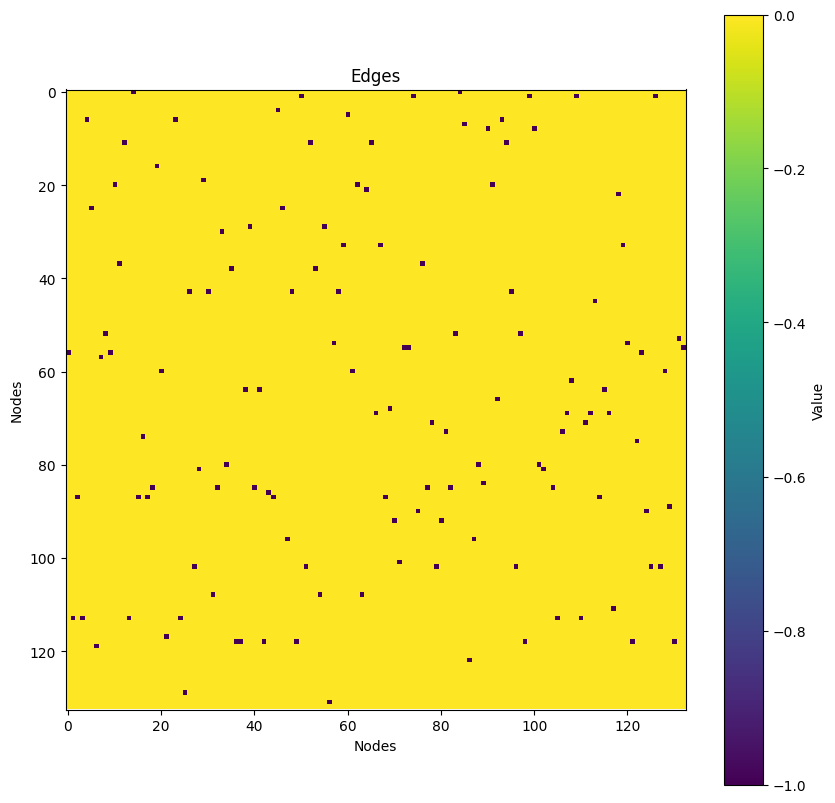

False
Parameter: comparison_func.W, Shape: torch.Size([60])
Parameter containing:
tensor([-5.8367e-02, -1.1879e+00, -3.2975e-01, -9.0556e-01,  7.6664e-01,
        -4.3913e-01, -1.1367e+00,  2.9569e-04,  2.1210e-02,  1.0400e+00,
         2.9028e-01,  3.2359e-01, -4.0002e-01,  1.5077e-01, -5.6985e-01,
         6.1493e-01,  1.6331e+00,  6.3317e-01, -1.1974e-01, -4.9205e-01,
         3.2448e-01, -6.3719e-01, -7.9789e-01, -6.6439e-01,  1.4107e+00,
        -7.7486e-01,  6.8237e-01,  1.1193e-01,  8.2757e-01,  2.5164e-01,
        -7.1775e-01, -1.2041e+00,  8.0860e-01, -1.3703e+00,  1.2159e+00,
         1.1347e+00, -1.8200e-01, -1.1336e-01, -1.2775e+00, -1.0517e+00,
         6.7948e-01, -7.5299e-01, -1.0382e+00,  1.8924e-01,  2.5323e+00,
        -7.2997e-01,  6.0077e-01, -9.4945e-01,  1.7203e+00,  1.0170e+00,
         3.3650e-01, -1.3741e+00, -1.5421e+00,  1.1419e+00,  4.4285e-01,
        -2.5866e-01,  2.7498e-01,  1.8774e+00,  1.2242e+00,  9.5467e-01],
       requires_grad=True)
Accuracy, Prec

In [71]:
reload_imports()
results = run_model(X_train, y_train, X_val, y_val, print_matrix=True, print_compute=True, print_params=True)
print("Accuracy, Precision, Recall, F1")
print(np.squeeze(results))

### Test Set

In [ ]:
# reload_imports()
# print("Accuracy, Precision, Recall, F1")
# run_model(X_train_full, y_train_full, X_test, y_test, show_graph=False)